# 01 — Visão geral dos dados sintéticos

Este notebook explora `data/datasets_gerados/objetos_sinteticos.csv`, a cena sintética de objetos 2D usada em todo o projeto de raciocínio espacial neuro-simbólico (ver `src/data_generator.py`).

Cada objeto possui posição `(x, y)`, cor, forma, tamanho e um `vetor_11` — a representação numérica usada pelos predicados LTN.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    """Localiza a raiz do projeto subindo diretórios até achar src/ e requirements.txt."""
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "datasets_gerados"
RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
QUERIES_DIR = RESULTS_DIR / "queries"
TRAINING_DIR = RESULTS_DIR / "training"

print("Raiz do projeto:", PROJECT_ROOT)


Raiz do projeto: C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch


## Carregando os objetos

In [2]:
df_objetos = pd.read_csv(DATA_DIR / "objetos_sinteticos.csv")
print(f"Total de objetos: {len(df_objetos)}")
df_objetos.head(10)

Total de objetos: 25


,id_objeto,x,y,cor,forma,tamanho,vetor_11
0,0,0.7740,0.4389,verde,triangulo,pequeno,"[0.7739560485559633, 0.4388784397520523, 0.0, ..."
1,1,0.0942,0.9756,azul,cone,grande,"[0.09417734788764953, 0.9756223516367559, 0.0,..."
2,2,0.7861,0.1281,azul,cilindro,grande,"[0.7860643052769538, 0.12811363267554587, 0.0,..."
3,3,0.9268,0.6439,verde,cilindro,grande,"[0.9267649888486018, 0.6438651200806645, 0.0, ..."
4,4,0.4434,0.2272,vermelho,cilindro,grande,"[0.44341419882733113, 0.2272387217847769, 1.0,..."
5,5,0.8276,0.6317,vermelho,circulo,grande,"[0.8276311719925821, 0.6316643991220648, 1.0, ..."
6,6,0.3545,0.9707,verde,triangulo,grande,"[0.35452596812986836, 0.9706980243949033, 0.0,..."
7,7,0.1946,0.4667,azul,cilindro,pequeno,"[0.19463870785196757, 0.4667210037270342, 0.0,..."
8,8,0.1543,0.6830,azul,cone,pequeno,"[0.15428949206754783, 0.6830489532424546, 0.0,..."
9,9,0.3258,0.3705,azul,circulo,pequeno,"[0.32582535813815194, 0.3704597060348689, 0.0,..."


## Distribuição de atributos categóricos

Cada objeto tem exatamente uma cor, uma forma e um tamanho (mutuamente exclusivos — ver axiomas de taxonomia em `src/ltn_axioms.py`).

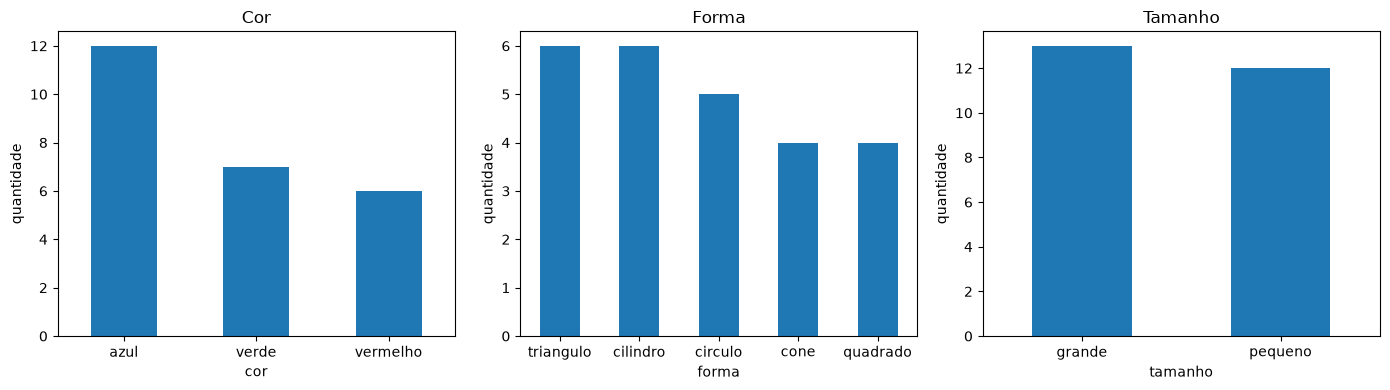

In [3]:
fig, eixos = plt.subplots(1, 3, figsize=(14, 4))

df_objetos["cor"].value_counts().plot(kind="bar", ax=eixos[0], title="Cor")
df_objetos["forma"].value_counts().plot(kind="bar", ax=eixos[1], title="Forma")
df_objetos["tamanho"].value_counts().plot(kind="bar", ax=eixos[2], title="Tamanho")

for eixo in eixos:
    eixo.set_ylabel("quantidade")
    eixo.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Distribuição espacial (x, y)

In [4]:
df_objetos[["x", "y"]].describe()

,x,y
count,25.000000,25.000000
mean,0.447732,0.458616
std,0.275625,0.260917
min,0.022700,0.030800
25%,0.194600,0.281400
50%,0.406400,0.438900
75%,0.669800,0.634700
max,0.926800,0.975600


## Estrutura do `vetor_11`

```text
[0]      posição x normalizada
[1]      posição y normalizada
[2:5]    cor one-hot: vermelho, verde, azul
[5:10]   forma one-hot: circulo, quadrado, cilindro, cone, triangulo
[10]     tamanho: pequeno = 0.0, grande = 1.0
```

In [5]:
exemplo = df_objetos.iloc[0]
vetor = json.loads(exemplo["vetor_11"])

print(f"Objeto {int(exemplo['id_objeto'])}: cor={exemplo['cor']}, "
      f"forma={exemplo['forma']}, tamanho={exemplo['tamanho']}")
print("vetor_11 =", [round(v, 4) for v in vetor])

Objeto 0: cor=verde, forma=triangulo, tamanho=pequeno
vetor_11 = [0.774, 0.4389, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
